## `Plot how final local lyapunov exponent changes with final loss for individual points.`

In [1]:
import json 
import matplotlib.pyplot as plt 
import seaborn as sns
import math
import pandas as pd 

import MODELS.model_param as g
import MODELS.Linear as lin  
import MODELS.Sigmoid as sig 
import MODELS.ReLU as relu  
import lyapk_vs_lr as LL

In [2]:
models = ["Linear", "Sigmoid", "ReLU"]
model_classes = [lin, sig, relu]
colors = ["blue", "green", "red"]
sns.set_style("darkgrid")

In [3]:
TURNS = 1000
df = None

def load_param_from_file(filename, param):
    var = None
    with open(f"{filename}", 'r') as file:
        var = json.load(file)
        return var[f"{param}"]

def iqr_treatement(x_arr, y_arr):
    global df
    f_col, s_col = [x[0] for x in x_arr], [x[1] for x in x_arr]
    df = pd.DataFrame(list(zip(f_col, s_col, y_arr)), columns=["Initial Loss", "Final Loss", "Lyapunov Exponent"])
    q1, q3 = df['Initial Loss'].quantile(0.45), df['Initial Loss'].quantile(0.55)
    df_new = df[ (df['Initial Loss'] >= q1) & (df['Initial Loss'] <= q3) ]
    return df_new

def lyapk_vs_loss(class_nn, filename, model, color = None, ax = None):
    y_arr, x_arr = [], []
    for _ in range(TURNS):
        class_nn.run_model()
        dist = load_param_from_file(f"{filename}", "avg_dist")
        lyapk = [math.log(dist[i]/dist[0]) for i in range(1, len(dist))]
        avg_lyapk = sum(lyapk)/len(lyapk)
        loss = load_param_from_file(f"{filename}", "loss")
        y_arr.append(avg_lyapk)
        x_arr.append([loss[0][0],loss[0][-1]])

    df = iqr_treatement(x_arr, y_arr)
    sns.regplot(data = df, x = 'Final Loss', y = 'Lyapunov Exponent', color = color, ax = ax)
    ax.set_title(f"{model}")

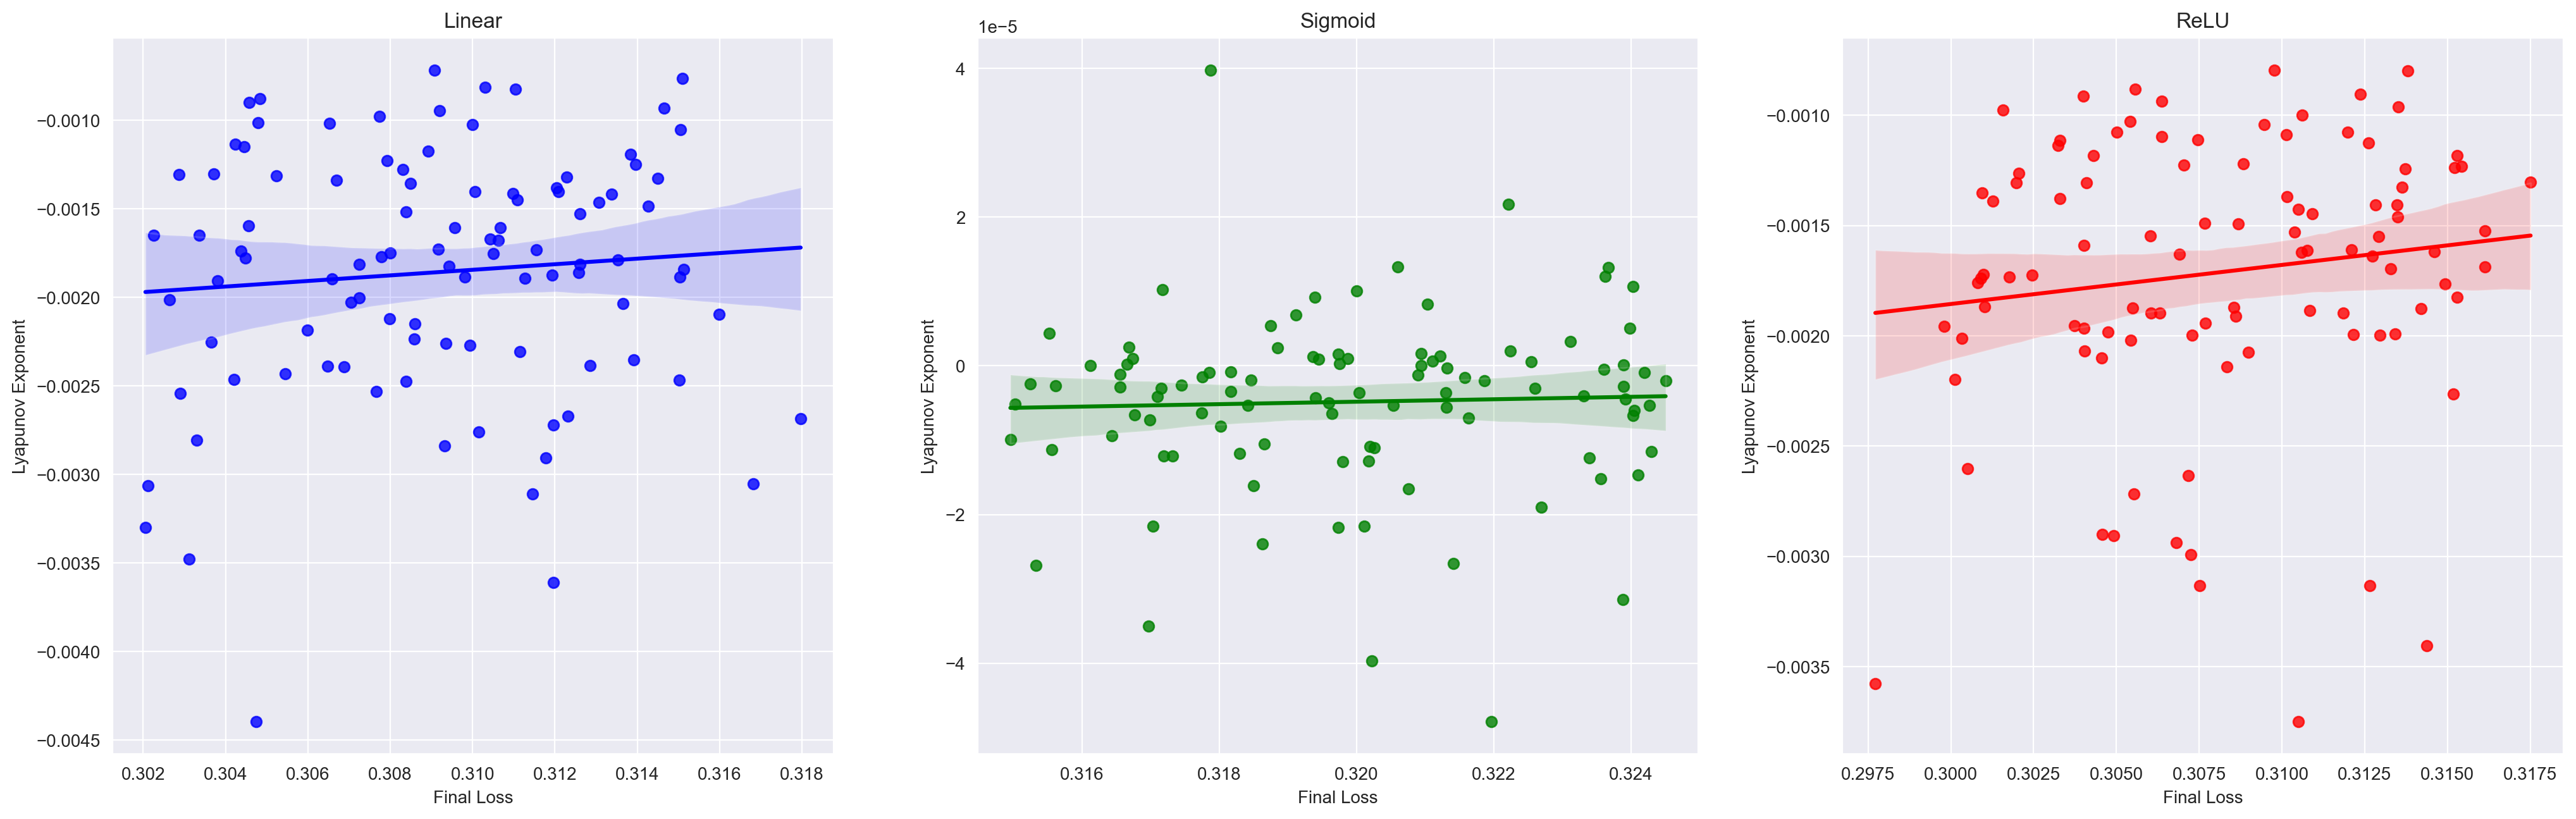

In [4]:
g.set_lr(0.001)
fig, ax = plt.subplots(1, 3, figsize = (25, 7.5), dpi = 200)
for idx, model in enumerate(models):
    lyapk_vs_loss(model_classes[idx], f'RAW_DATA/{model}.json', model, color = colors[idx], ax = ax[idx])
plt.savefig(f'PLOTS/LyapunovVsLoss.png')
plt.show()

## `Plot how distance, lyapunov, loss changes over epochs.`

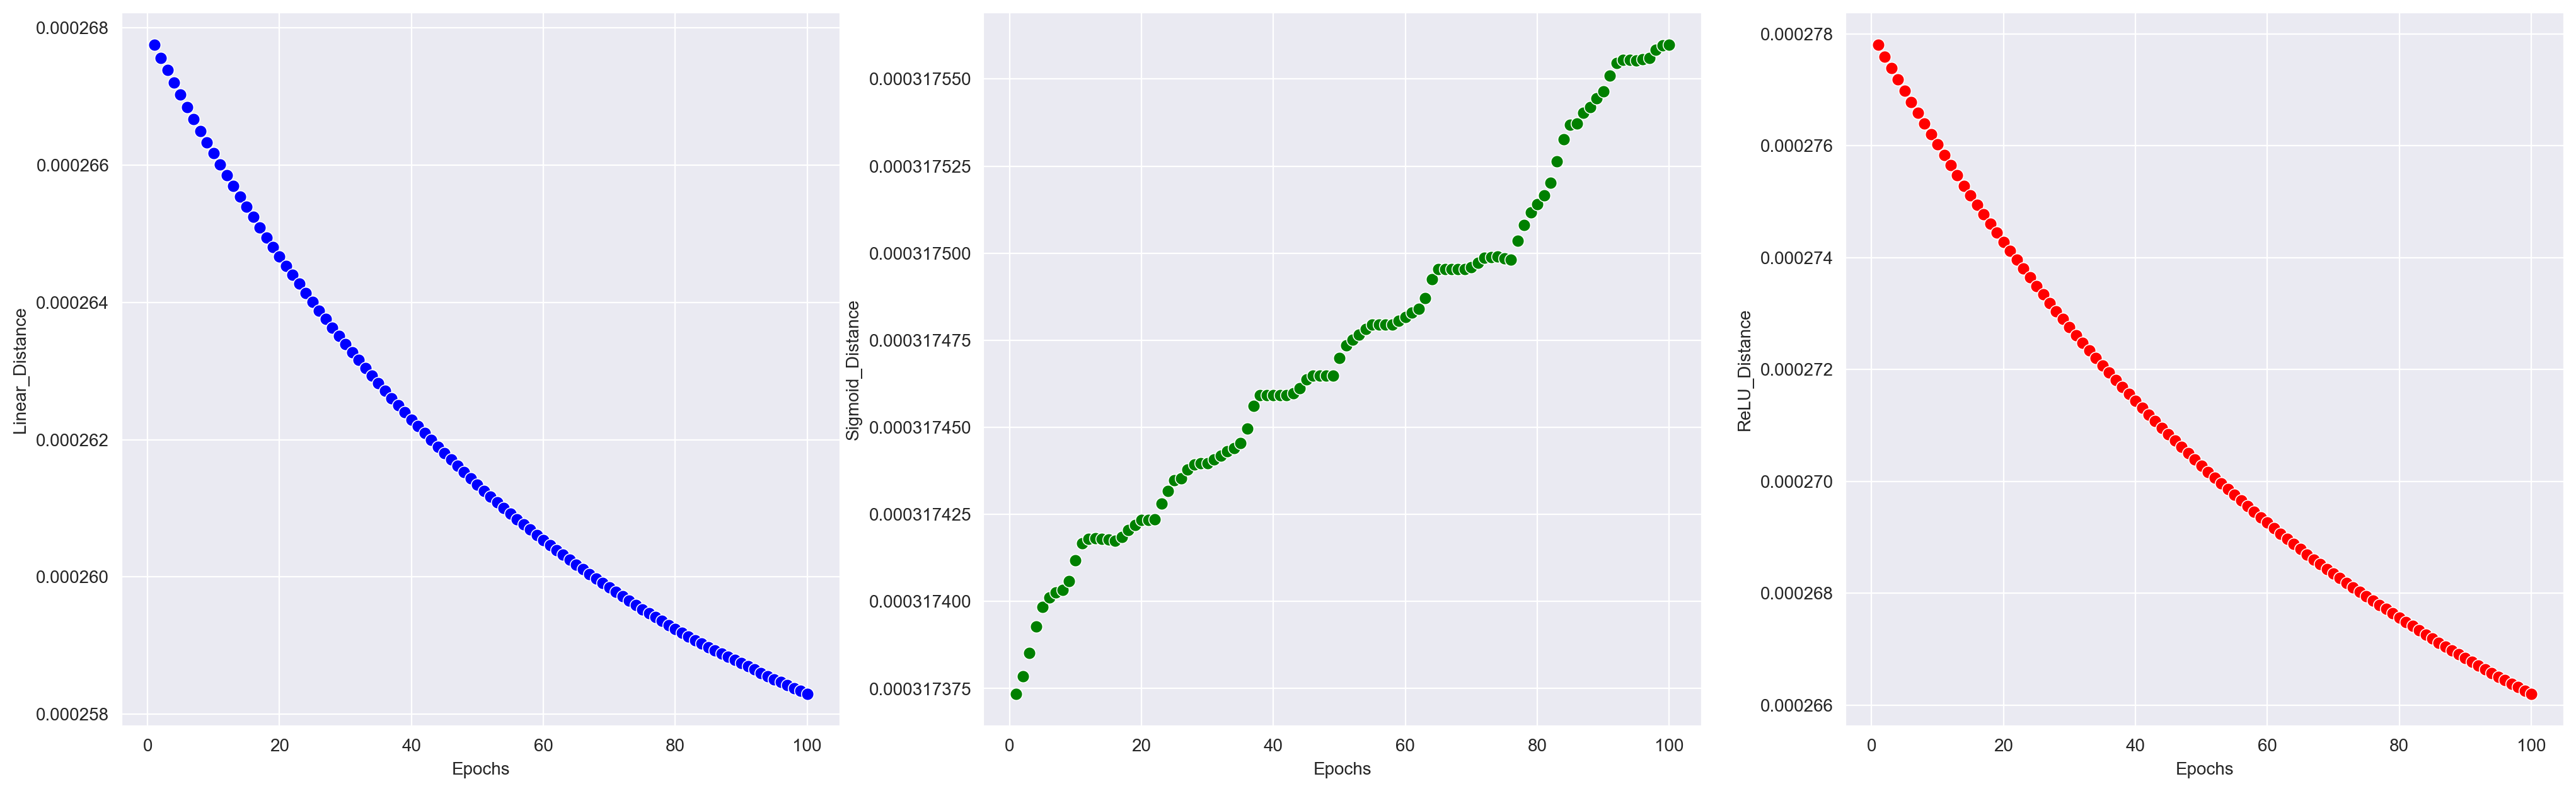

In [5]:
def plot_distance(class_nn, model_name, color='green', ax = None):
    '''
    How distance evolves over epochs.
    '''
    class_nn.run_model()
    dist = load_param_from_file(f"RAW_DATA/{model_name}.json", "avg_dist")
    sns.scatterplot(x = [_ for _ in range(1, len(dist)+1)], y = dist, s = 50, color = color, ax = ax)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(f'{model_name}_Distance')
    

g.set_epochs(100)
fig, axes = plt.subplots(1, len(models), figsize = (25, 7.5), dpi = 200)
for idx, model in enumerate(models):
    plot_distance(model_classes[idx], model, color = colors[idx], ax = axes[idx])
plt.savefig(f'PLOTS/DistanceVsEpochs.png')
plt.show()


Avg Lyapk Linear: -0.0002289860929824457
Avg Lyapk Sigmoid: 1.724561883878755e-06
Avg Lyapk ReLU: -0.0003091404313753573


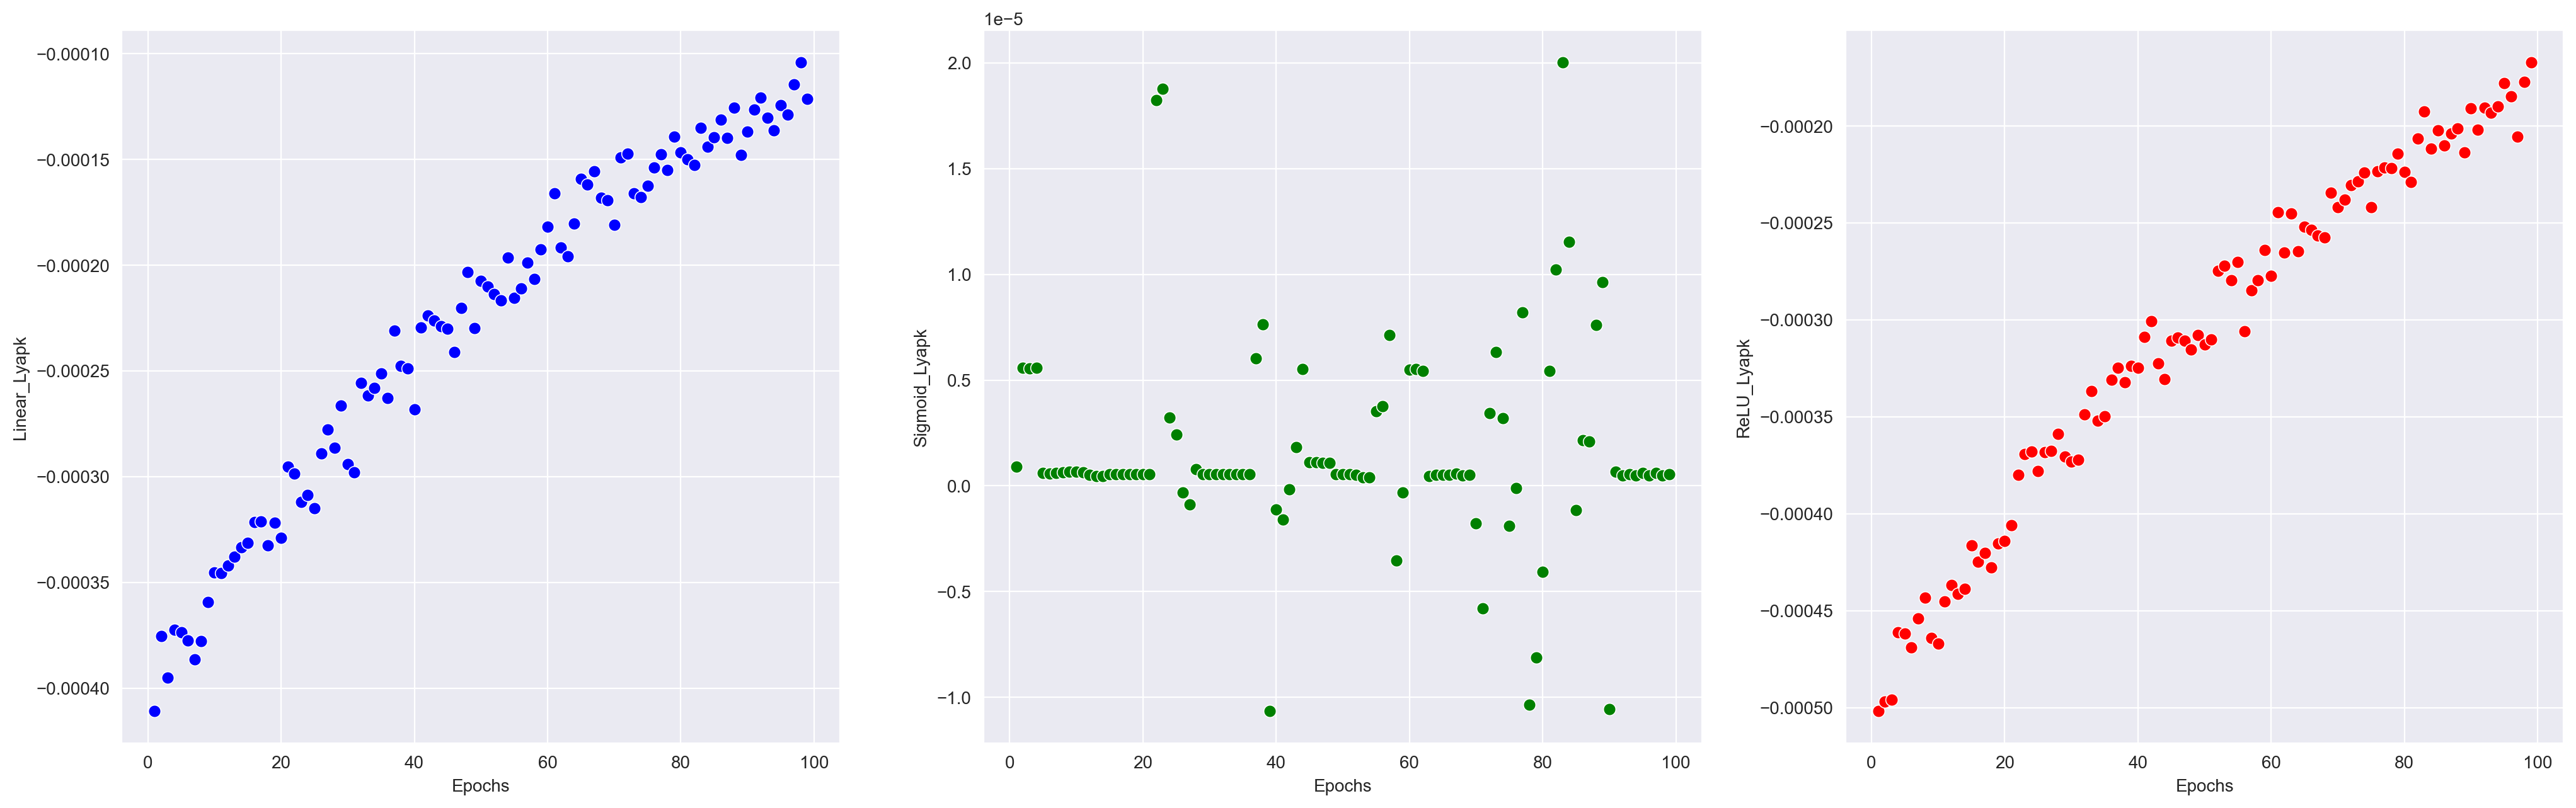

In [6]:
def plot_lyapk(class_nn, model_name, color = None, ax = None):
    '''
    How Lyapunov Exponents change over epochs.
    '''
    class_nn.run_model()
    dist = load_param_from_file(f"RAW_DATA/{model_name}.json", "avg_dist")
    lyapk = [math.log(abs(dist[i]/dist[i-1])) for i in range(1, len(dist))]
    sns.scatterplot(x = [_ for _ in range(1, len(lyapk)+1)], y = lyapk, s=50, color = color, ax = ax)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(f'{model_name}_Lyapk')
    print(f'Avg Lyapk {model_name}: {sum(lyapk)/len(lyapk)}')

g.set_epochs(100)
fig, axes = plt.subplots(1, len(models), figsize = (25, 7.5), dpi = 200)
for idx, model in enumerate(models):
    plot_lyapk(model_classes[idx], model, color = colors[idx], ax = axes[idx])
plt.savefig(f'PLOTS/LyapkVsEpochs.png')
plt.show()

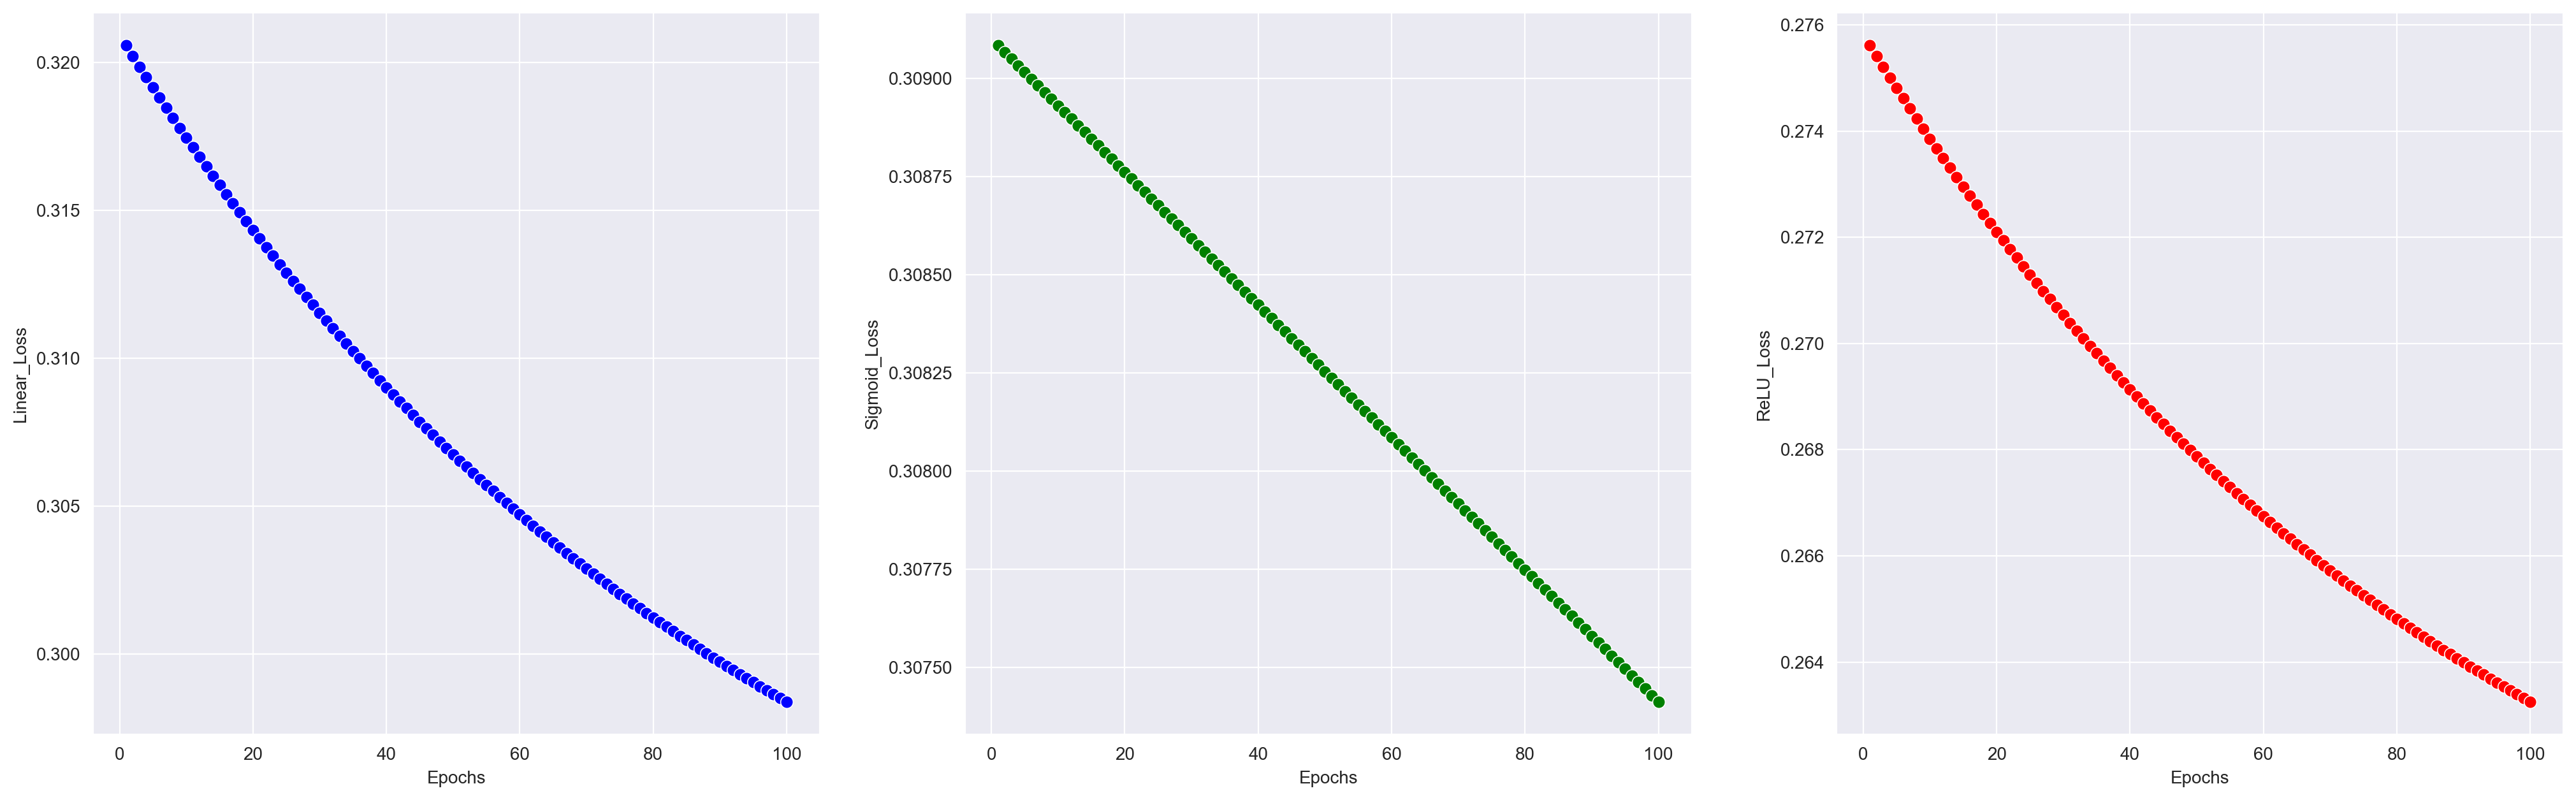

In [7]:
def plot_loss(class_nn, model_name, indx = 0, color = None, ax = None):
    '''
    How loss of i-th point (parent/children) changes over epochs.
    '''
    class_nn.run_model()
    loss = load_param_from_file(f"RAW_DATA/{model_name}.json", "loss")
    sns.scatterplot(x = [_ for _ in range(1, len(loss[indx])+1)], y = loss[indx], s=50, color = color, ax = ax)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(f'{model_name}_Loss')

g.set_epochs(100)
fig, axes = plt.subplots(1, len(models), figsize = (25, 7.5), dpi = 200)
for idx, model in enumerate(models):
    plot_loss(model_classes[idx], model, 0, color = colors[idx], ax = axes[idx])
plt.savefig(f'PLOTS/LossVsEpochs.png')
plt.show()

## `Calculates if different learning rate can induce chaos.`

In [8]:
def plot_graph(save_op_file, model, default_color = None, ax = None):
    with open(f"{save_op_file}", "r") as file:
        j_dict = json.load(file)
        lr_arr, lyapk_arr = j_dict["x"], j_dict["y"]
        sns.scatterplot(x=lr_arr, y=lyapk_arr, color = default_color, s=100, ax = ax)
        ax.set_xlabel('Learning rate.')
        ax.set_ylabel('Lyapunov Exponent.')
        ax.set_title(f'{model}')

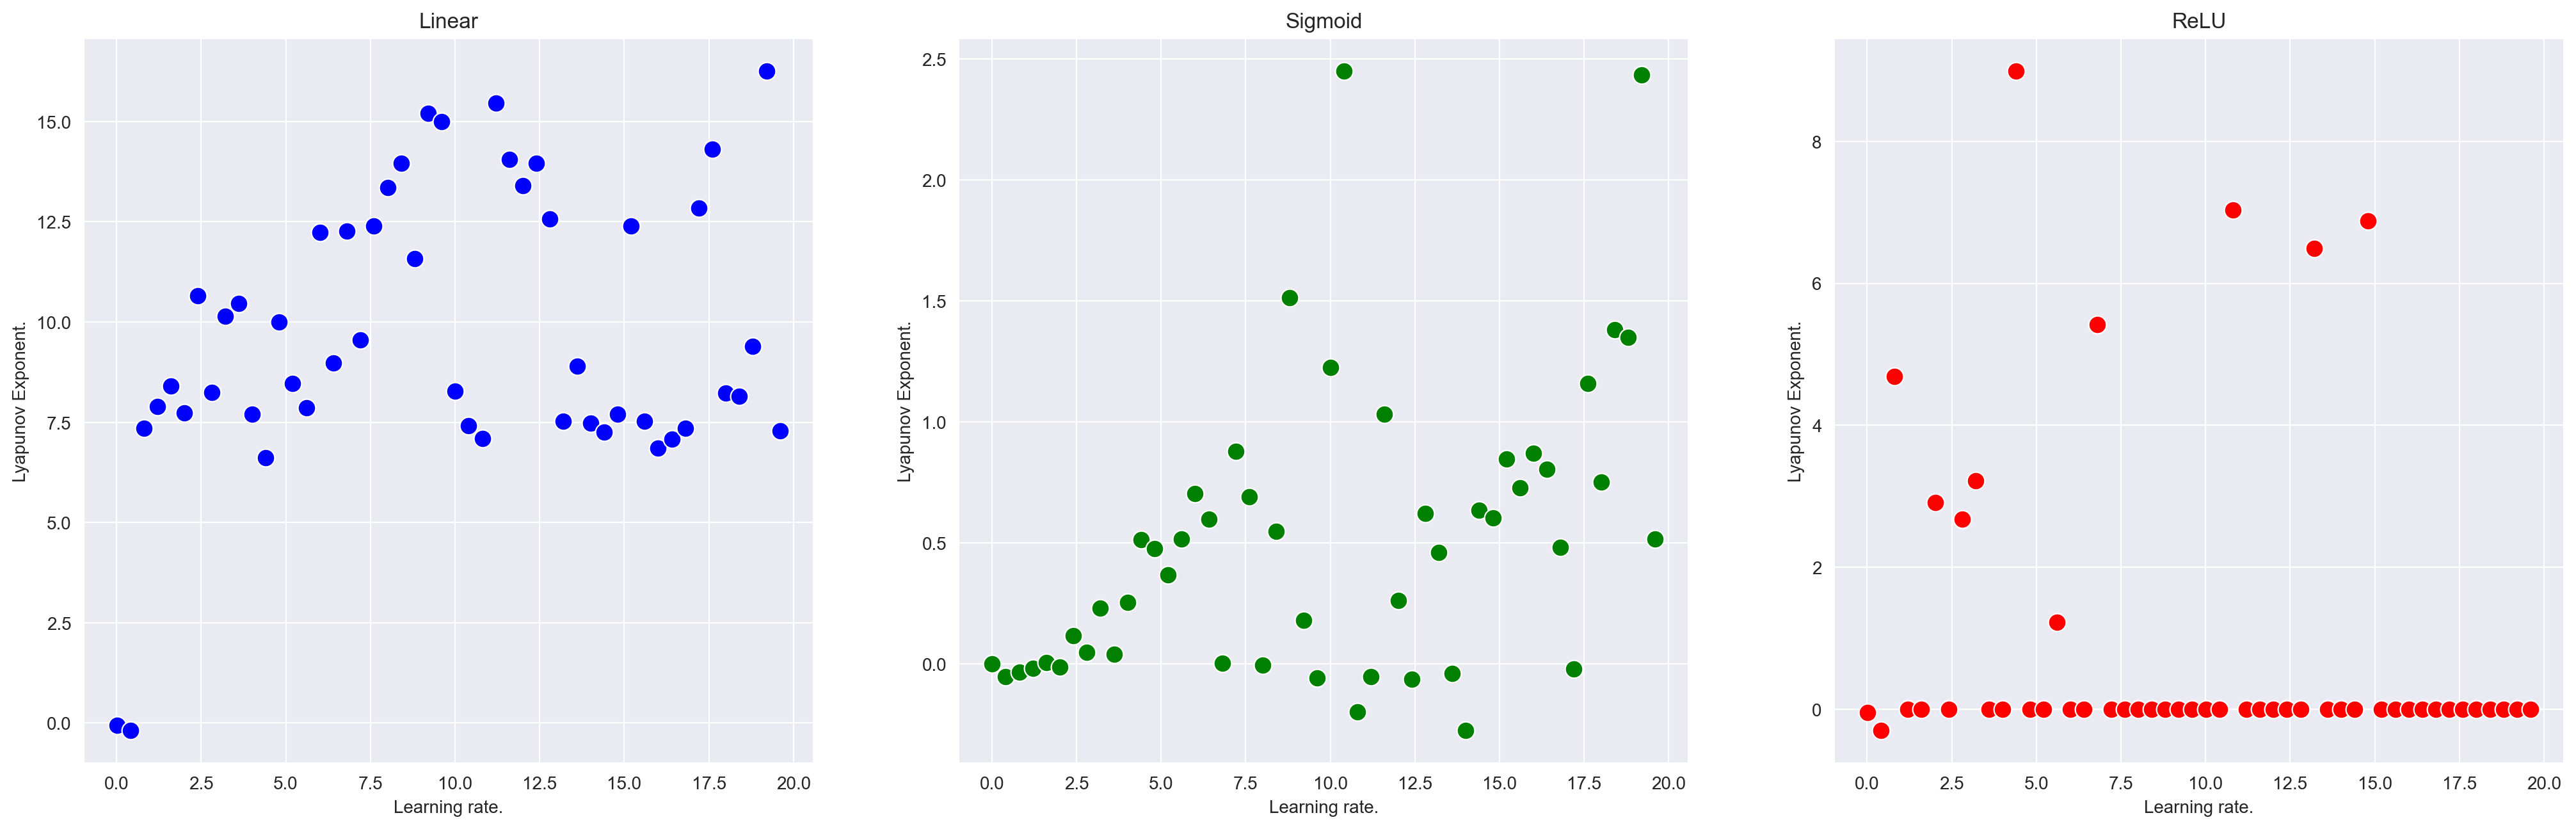

In [9]:
fig, ax = plt.subplots(1, 3, figsize = (25, 7.5), dpi = 200)
for idx, model in enumerate(models):
    LL.run(model_classes[idx], f'RAW_DATA/{model}.json', f'RAW_DATA/{model}_LR_LUEXP.json', lb = 0.01, ub = 20, n_points = 50)
    plot_graph(f'RAW_DATA/{model}_LR_LUEXP.json', model, default_color = colors[idx], ax = ax[idx])

plt.savefig(f'PLOTS/LyapunovVsLearningRate.png')
plt.show()